# Phase 2 — Preprocessing Checks
**Longitudinal CBC Trend Analyzer**

This notebook runs the full preprocessing pipeline from `phase2_preprocessing.py` and provides:
- Raw data distributions for each CBC feature
- Pre vs post normalisation comparisons
- Time delta distributions (draw spacing)
- Anomaly label balance
- Window construction sanity checks
- Batch shape verification

> **Prerequisites:** Run `phase1_generate_data.py` first to create `data/cbc_synthetic.csv`

## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import warnings
import sys
import os

warnings.filterwarnings('ignore')

# ── Make sure we can import our preprocessing module ──────────────────────────

sys.path.append(os.path.abspath('../..'))

from phase2_preprocessing import (
    CBCPreprocessor,
    split_patients,
    build_windows,
    make_loaders,
    run_preprocessing,
    CBC_FEATURES,
    STATIC_CAT_COLS,
    WINDOW_SIZE,
    STRIDE,
)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
PALETTE = sns.color_palette('muted')
print('Setup complete.')

Setup complete.


## 1. Load Raw Data

In [2]:
CSV_PATH = '../data/cbc_synthetic.csv'  # adjust if needed

df = pd.read_csv(CSV_PATH)

print(f'Patients : {df["patient_id"].nunique()}')
print(f'Total rows: {len(df):,}')
print(f'Columns  : {list(df.columns)}')
df.head()

Patients : 500
Total rows: 20,097
Columns  : ['patient_id', 'timestamp_day', 'time_delta', 'WBC', 'ANC', 'RBC', 'HGB', 'PLT', 'LYM', 'MONO', 'anomaly_type', 'is_anomaly', 'age', 'sex', 'cancer_type', 'chemo_protocol']


,patient_id,timestamp_day,time_delta,WBC,ANC,RBC,HGB,PLT,LYM,MONO,anomaly_type,is_anomaly,age,sex,cancer_type,chemo_protocol
0,0,0.0,0.0,11.34,3.44,5.49,13.6,213,4.13,0.56,erratic,0,32,F,MM,BEP
1,0,12.0,12.0,4.65,1.21,2.22,5.8,96,1.83,0.24,erratic,0,32,F,MM,BEP
2,0,15.0,3.0,8.80,2.60,4.34,9.5,164,3.68,0.45,erratic,0,32,F,MM,BEP
3,0,25.0,10.0,10.87,2.78,4.74,11.2,201,4.05,0.53,erratic,0,32,F,MM,BEP
4,0,30.0,5.0,5.06,1.41,2.11,5.5,86,1.91,0.25,erratic,0,32,F,MM,BEP


## 2. Draws-Per-Patient Distribution
This tells us how many CBC measurements each patient has. 
Patients with fewer draws than `WINDOW_SIZE` will be skipped during windowing.

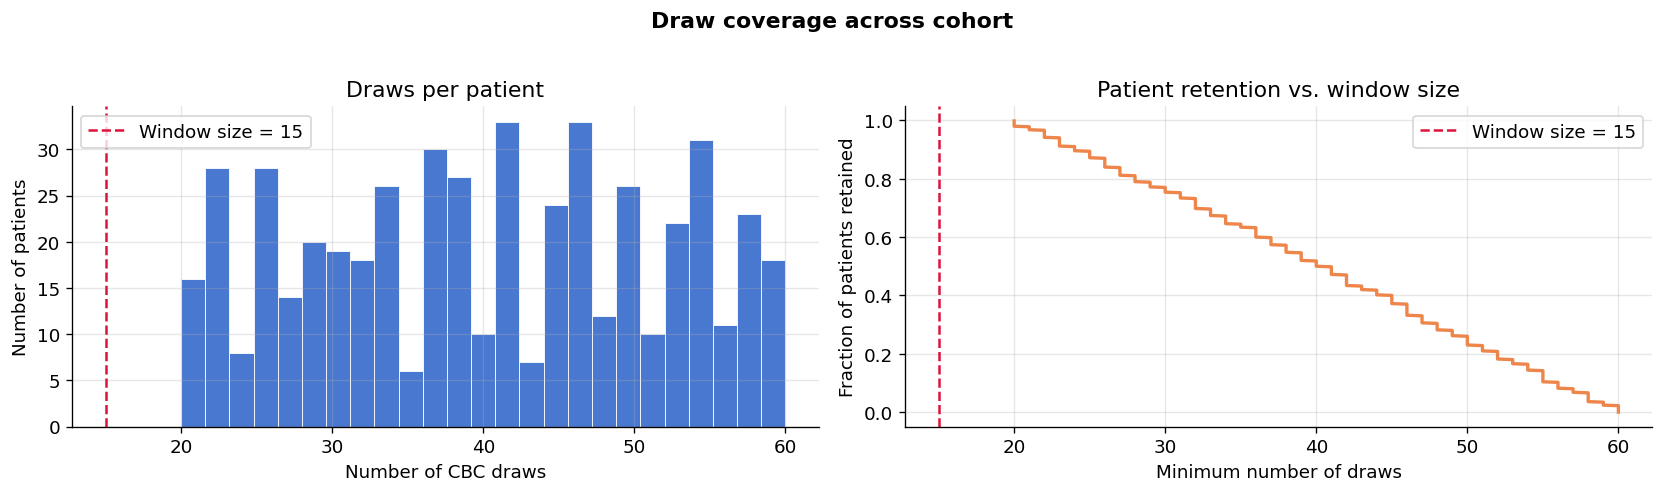

Patients with >= 15 draws: 100.0%
Min draws: 20  |  Median: 40  |  Max: 60


In [3]:
draws_per_patient = df.groupby('patient_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(draws_per_patient, bins=25, color=PALETTE[0], edgecolor='white', linewidth=0.5)
axes[0].axvline(WINDOW_SIZE, color='crimson', linestyle='--', linewidth=1.5, label=f'Window size = {WINDOW_SIZE}')
axes[0].set_xlabel('Number of CBC draws')
axes[0].set_ylabel('Number of patients')
axes[0].set_title('Draws per patient')
axes[0].legend()

# Cumulative — what % of patients have >= N draws?
sorted_draws = np.sort(draws_per_patient)
cdf = np.arange(1, len(sorted_draws) + 1) / len(sorted_draws)
axes[1].plot(sorted_draws, 1 - cdf, color=PALETTE[1], linewidth=2)
axes[1].axvline(WINDOW_SIZE, color='crimson', linestyle='--', linewidth=1.5, label=f'Window size = {WINDOW_SIZE}')
axes[1].set_xlabel('Minimum number of draws')
axes[1].set_ylabel('Fraction of patients retained')
axes[1].set_title('Patient retention vs. window size')
axes[1].legend()

plt.suptitle('Draw coverage across cohort', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

pct_eligible = (draws_per_patient >= WINDOW_SIZE).mean() * 100
print(f'Patients with >= {WINDOW_SIZE} draws: {pct_eligible:.1f}%')
print(f'Min draws: {draws_per_patient.min()}  |  Median: {draws_per_patient.median():.0f}  |  Max: {draws_per_patient.max()}')

## 3. Raw CBC Feature Distributions
Histograms of all 7 CBC features **before normalisation**.
Red dashed lines show the clinical normal range.

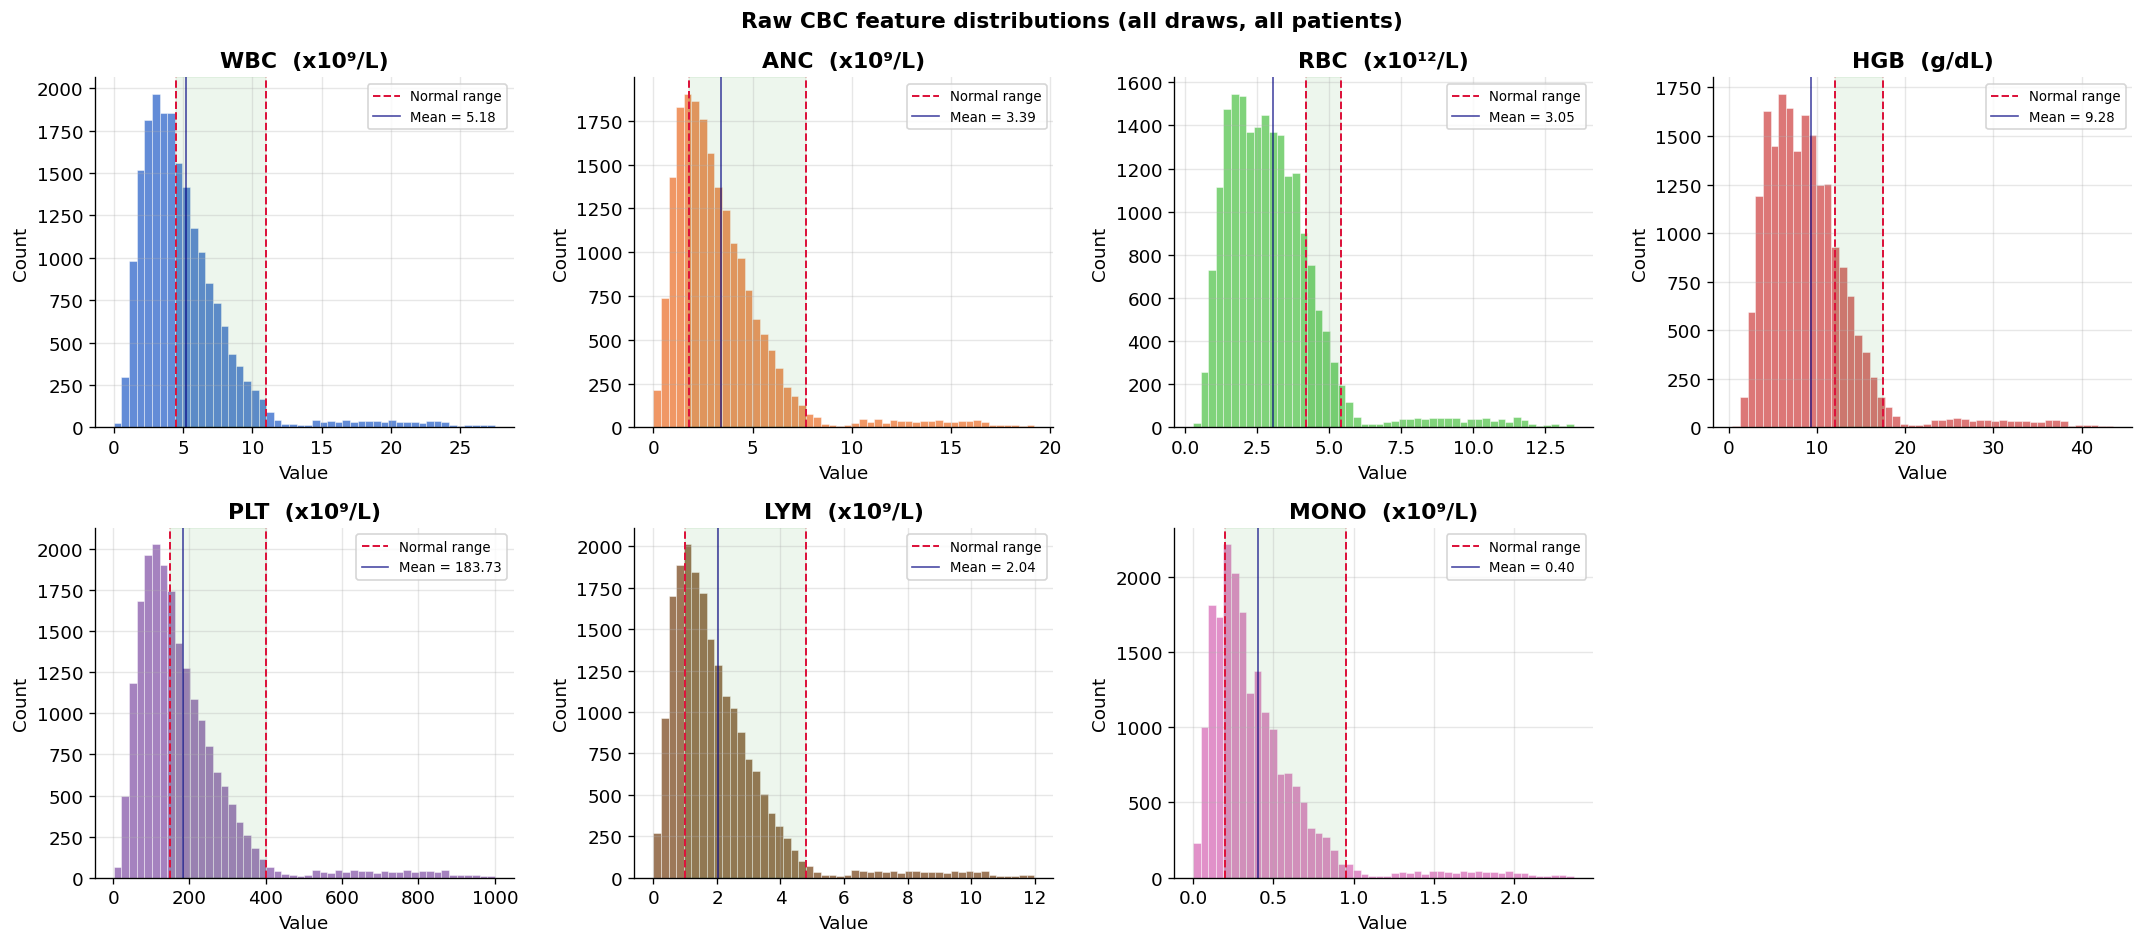

In [4]:
# Clinical normal ranges (from phase1_generate_data.py)
NORMAL_RANGES = {
    'WBC':  (4.5,  11.0),
    'ANC':  (1.8,   7.7),
    'RBC':  (4.2,   5.4),
    'HGB':  (12.0, 17.5),
    'PLT':  (150,  400),
    'LYM':  (1.0,   4.8),
    'MONO': (0.2,   0.95),
}

UNITS = {
    'WBC': 'x10⁹/L', 'ANC': 'x10⁹/L', 'RBC': 'x10¹²/L',
    'HGB': 'g/dL',   'PLT': 'x10⁹/L', 'LYM': 'x10⁹/L', 'MONO': 'x10⁹/L'
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(CBC_FEATURES):
    ax = axes[i]
    data = df[feat].dropna()
    lo, hi = NORMAL_RANGES[feat]

    ax.hist(data, bins=50, color=PALETTE[i % len(PALETTE)], edgecolor='white', linewidth=0.3, alpha=0.85)
    ax.axvline(lo, color='crimson', linestyle='--', linewidth=1.2, label='Normal range')
    ax.axvline(hi, color='crimson', linestyle='--', linewidth=1.2)
    ax.axvspan(lo, hi, alpha=0.07, color='green')
    ax.set_title(f'{feat}  ({UNITS[feat]})', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

    # Annotate mean
    ax.axvline(data.mean(), color='navy', linestyle='-', linewidth=1.0, alpha=0.7, label=f'Mean = {data.mean():.2f}')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)  # hide the 8th subplot (only 7 features)

plt.suptitle('Raw CBC feature distributions (all draws, all patients)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Anomaly Label Distribution
Check the class balance across patients and across individual draws.

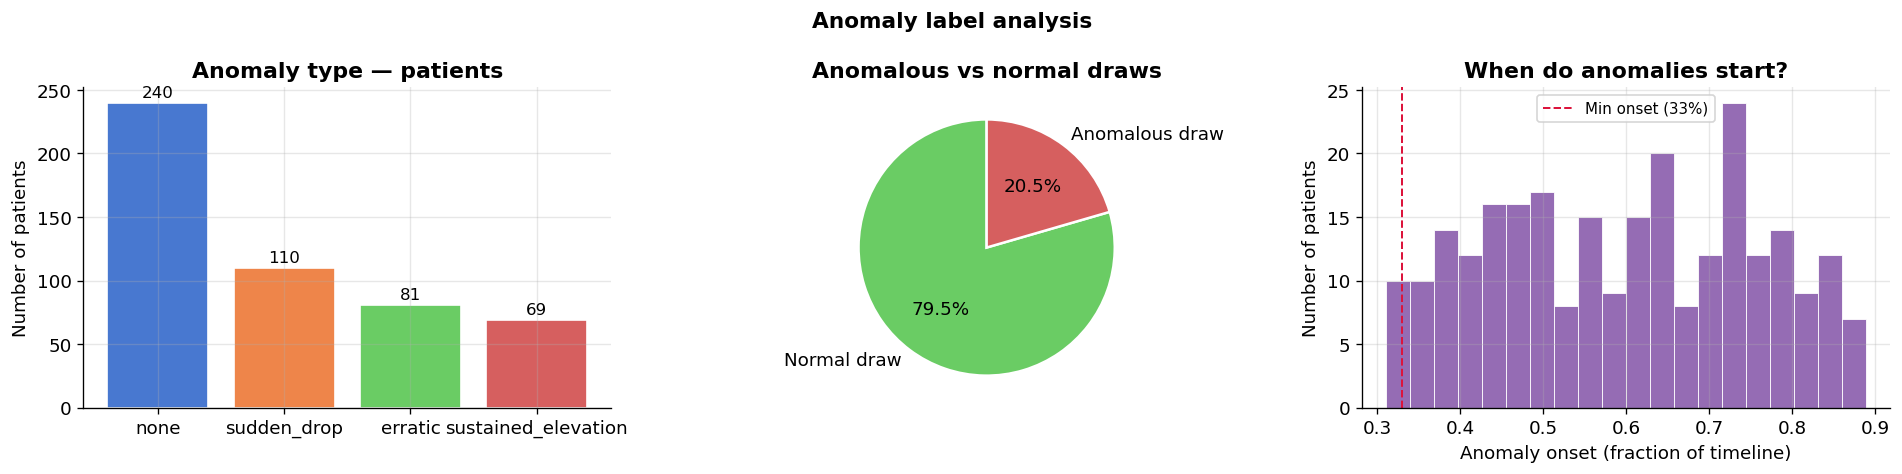

Overall anomalous draw rate: 20.5%


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Plot 1: Anomaly type per patient ──────────────────────────────────────────
patient_anom = df.drop_duplicates('patient_id')['anomaly_type'].value_counts()
bars = axes[0].bar(patient_anom.index, patient_anom.values,
                   color=[PALETTE[i] for i in range(len(patient_anom))],
                   edgecolor='white')
axes[0].set_title('Anomaly type — patients', fontweight='bold')
axes[0].set_ylabel('Number of patients')
axes[0].set_xlabel('')
for bar, val in zip(bars, patient_anom.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontsize=10)

# ── Plot 2: Anomalous vs normal draws (binary) ────────────────────────────────
draw_anom = df['is_anomaly'].value_counts()
labels = ['Normal draw', 'Anomalous draw']
axes[1].pie(
    draw_anom.values,
    labels=[labels[i] for i in draw_anom.index],
    colors=[PALETTE[2], PALETTE[3]],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Anomalous vs normal draws', fontweight='bold')

# ── Plot 3: Anomaly onset — how far into timeline? ───────────────────────────
anom_patients = df[df['anomaly_type'] != 'none'].copy()
onset_fractions = []
for pid, grp in anom_patients.groupby('patient_id'):
    grp = grp.sort_values('timestamp_day')
    first_anom_idx = grp['is_anomaly'].values.argmax()
    onset_fractions.append(first_anom_idx / len(grp))

axes[2].hist(onset_fractions, bins=20, color=PALETTE[4], edgecolor='white', linewidth=0.5)
axes[2].set_xlabel('Anomaly onset (fraction of timeline)')
axes[2].set_ylabel('Number of patients')
axes[2].set_title('When do anomalies start?', fontweight='bold')
axes[2].axvline(0.33, color='crimson', linestyle='--', linewidth=1.2, label='Min onset (33%)')
axes[2].legend(fontsize=9)

plt.suptitle('Anomaly label analysis', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Overall anomalous draw rate: {df['is_anomaly'].mean()*100:.1f}%")

## 5. Time Delta Distribution
How many days pass between consecutive CBC draws?
This motivates the **log-scaling** of `time_delta` — the raw distribution is right-skewed.

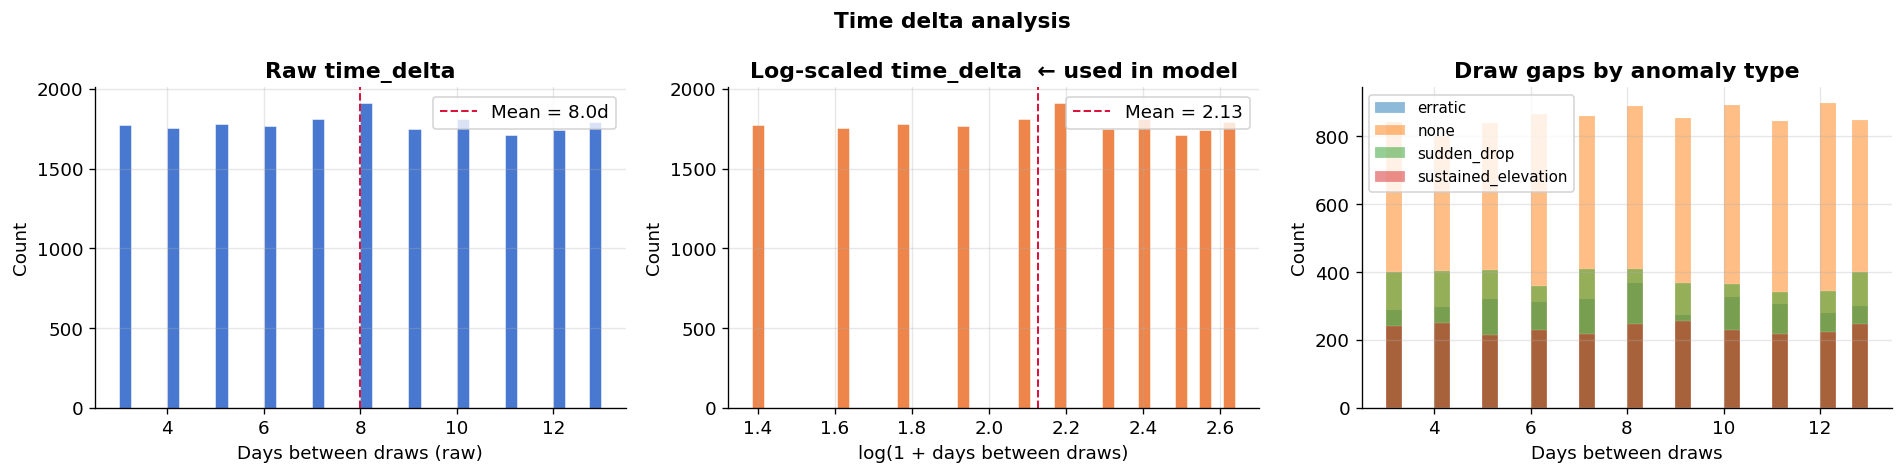

Draw gap stats (days):
  Min    : 3
  Median : 8
  Mean   : 8.0
  Max    : 13


In [6]:
# time_delta=0 for first draw of each patient — exclude those
deltas = df[df['time_delta'] > 0]['time_delta']
log_deltas = np.log1p(deltas)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw distribution
axes[0].hist(deltas, bins=40, color=PALETTE[0], edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Days between draws (raw)')
axes[0].set_ylabel('Count')
axes[0].set_title('Raw time_delta', fontweight='bold')
axes[0].axvline(deltas.mean(), color='crimson', linestyle='--', linewidth=1.2,
                label=f'Mean = {deltas.mean():.1f}d')
axes[0].legend()

# Log-scaled distribution
axes[1].hist(log_deltas, bins=40, color=PALETTE[1], edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('log(1 + days between draws)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-scaled time_delta  ← used in model', fontweight='bold')
axes[1].axvline(log_deltas.mean(), color='crimson', linestyle='--', linewidth=1.2,
                label=f'Mean = {log_deltas.mean():.2f}')
axes[1].legend()

# QQ-style: gap distributions by anomaly type
for atype, grp in df[df['time_delta'] > 0].groupby('anomaly_type'):
    axes[2].hist(grp['time_delta'], bins=30, alpha=0.5, label=atype, edgecolor='white', linewidth=0.2)
axes[2].set_xlabel('Days between draws')
axes[2].set_ylabel('Count')
axes[2].set_title('Draw gaps by anomaly type', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Time delta analysis', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Draw gap stats (days):")
print(f"  Min    : {deltas.min():.0f}")
print(f"  Median : {deltas.median():.0f}")
print(f"  Mean   : {deltas.mean():.1f}")
print(f"  Max    : {deltas.max():.0f}")

## 6. Train / Val / Test Split & Fit Preprocessor
We split at the **patient level**, then fit normalisation statistics on training data only.

Split → train: 350 pts | val: 75 pts | test: 75 pts


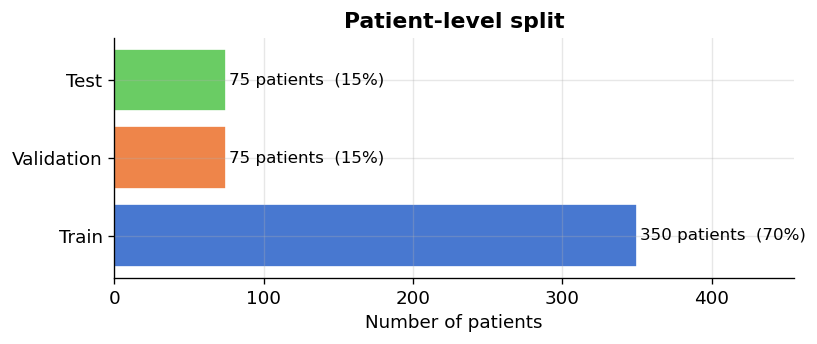

In [7]:
train_ids, val_ids, test_ids = split_patients(df)

train_df = df[df['patient_id'].isin(train_ids)]
val_df   = df[df['patient_id'].isin(val_ids)]
test_df  = df[df['patient_id'].isin(test_ids)]

preprocessor = CBCPreprocessor()
train_df_t   = preprocessor.fit_transform(train_df)
val_df_t     = preprocessor.transform(val_df)
test_df_t    = preprocessor.transform(test_df)

# Split sizes
fig, ax = plt.subplots(figsize=(7, 3))
splits = ['Train', 'Validation', 'Test']
counts = [len(train_ids), len(val_ids), len(test_ids)]
colors = [PALETTE[0], PALETTE[1], PALETTE[2]]
bars = ax.barh(splits, counts, color=colors, edgecolor='white')
for bar, val in zip(bars, counts):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val} patients  ({val/sum(counts)*100:.0f}%)',
            va='center', fontsize=10)
ax.set_xlabel('Number of patients')
ax.set_title('Patient-level split', fontweight='bold')
ax.set_xlim(0, max(counts) * 1.3)
plt.tight_layout()
plt.show()

## 7. Pre vs Post Normalisation Comparison
Each CBC feature should be centred near 0 with unit variance after normalisation.

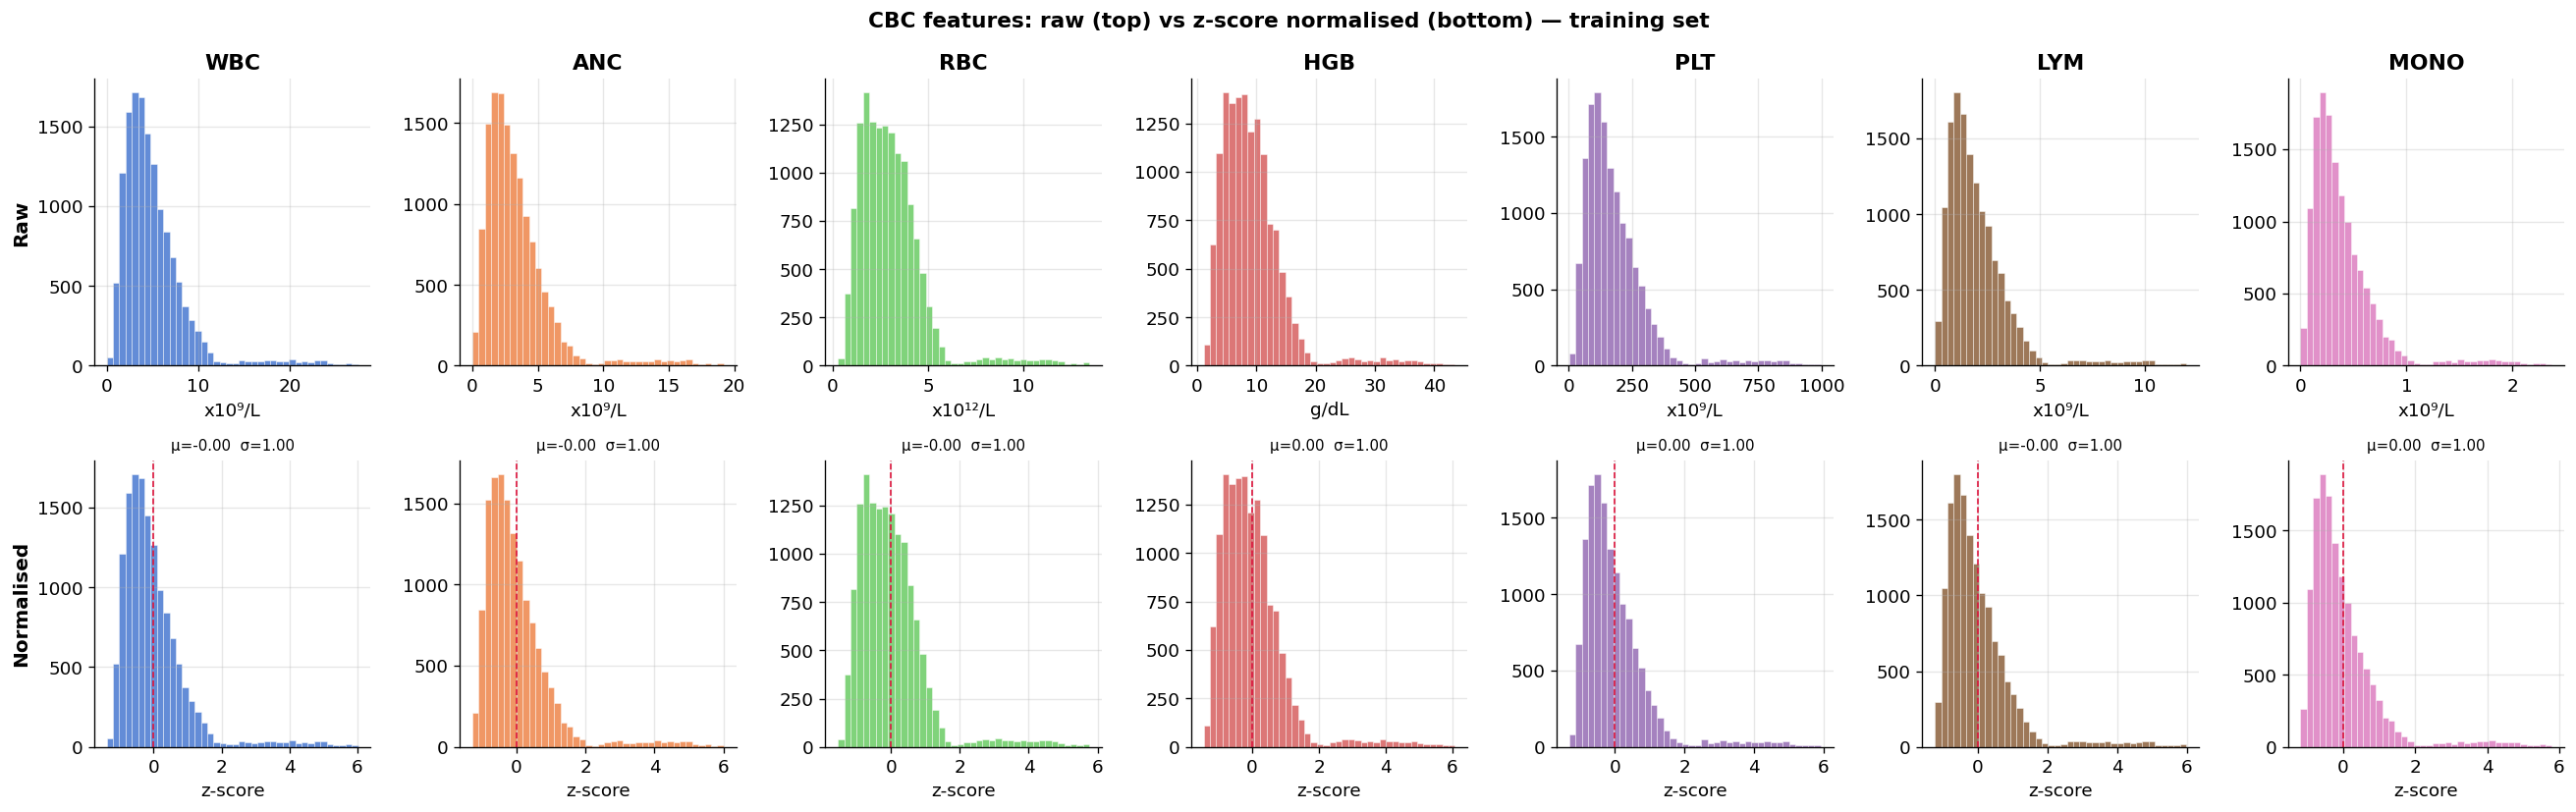

Post-normalisation stats (should be ~mean=0, std=1):
      WBC  ANC  RBC  HGB  PLT  LYM  MONO
mean -0.0 -0.0 -0.0  0.0  0.0 -0.0   0.0
std   1.0  1.0  1.0  1.0  1.0  1.0   1.0


In [8]:
fig, axes = plt.subplots(2, 7, figsize=(22, 7))

for i, feat in enumerate(CBC_FEATURES):
    raw  = train_df[feat].dropna()
    norm = train_df_t[feat].dropna()

    # Top row: raw
    axes[0, i].hist(raw, bins=40, color=PALETTE[i % len(PALETTE)],
                    edgecolor='white', linewidth=0.3, alpha=0.85)
    axes[0, i].set_title(feat, fontweight='bold')
    axes[0, i].set_xlabel(UNITS.get(feat, ''))
    if i == 0:
        axes[0, i].set_ylabel('Raw', fontsize=12, fontweight='bold')

    # Bottom row: normalised
    axes[1, i].hist(norm, bins=40, color=PALETTE[i % len(PALETTE)],
                    edgecolor='white', linewidth=0.3, alpha=0.85)
    axes[1, i].axvline(0, color='crimson', linestyle='--', linewidth=1.0)
    axes[1, i].set_xlabel('z-score')
    if i == 0:
        axes[1, i].set_ylabel('Normalised', fontsize=12, fontweight='bold')

    # Annotate mean and std
    axes[1, i].set_title(f'μ={norm.mean():.2f}  σ={norm.std():.2f}', fontsize=9)

plt.suptitle('CBC features: raw (top) vs z-score normalised (bottom) — training set',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Numerical summary
print('Post-normalisation stats (should be ~mean=0, std=1):')
stats = train_df_t[CBC_FEATURES].describe().loc[['mean', 'std']]
print(stats.round(3).to_string())

## 8. Feature Correlation Heatmap
CBC features are biologically correlated (e.g. WBC and ANC both reflect neutrophil count).
High correlation is expected and normal — this is just for awareness.

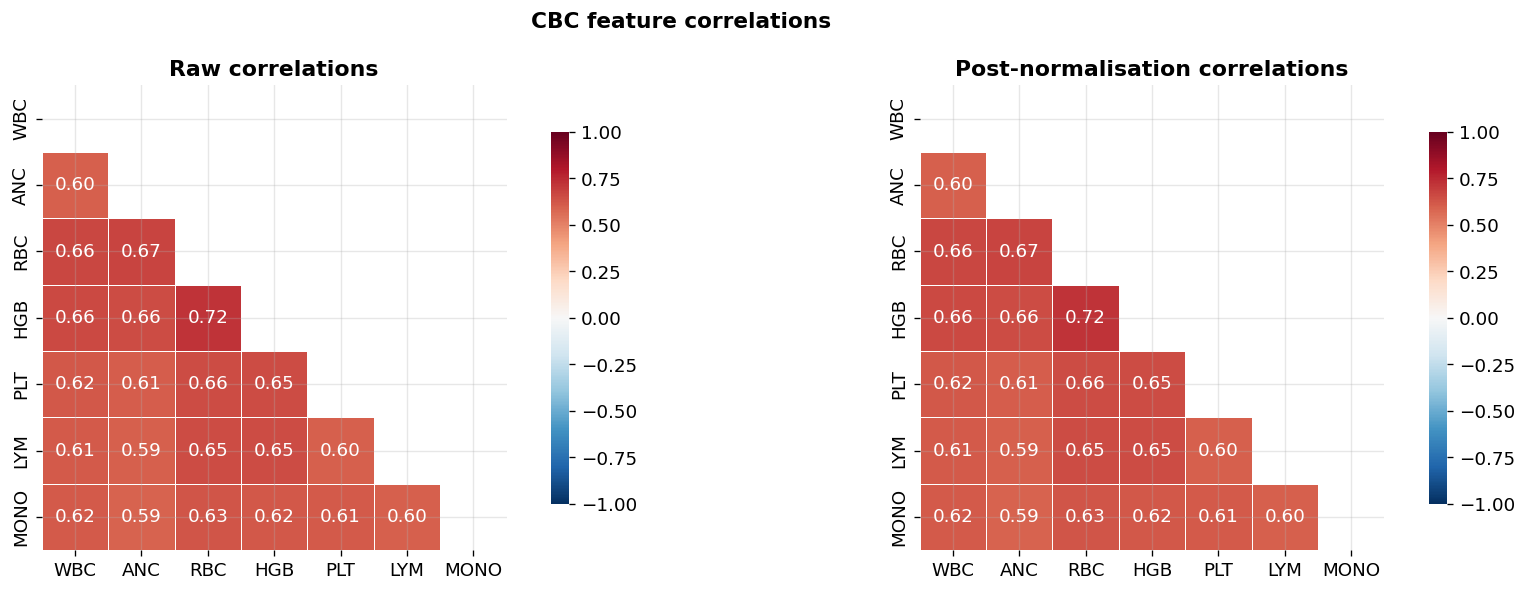

Note: WBC↔ANC correlation is expected — ANC is a WBC sub-fraction.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, data, title in [
    (axes[0], train_df[CBC_FEATURES],   'Raw correlations'),
    (axes[1], train_df_t[CBC_FEATURES], 'Post-normalisation correlations'),
]:
    corr = data.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, ax=ax, mask=mask,
        annot=True, fmt='.2f', linewidths=0.5,
        cmap='RdBu_r', vmin=-1, vmax=1,
        square=True, cbar_kws={'shrink': 0.8}
    )
    ax.set_title(title, fontweight='bold')

plt.suptitle('CBC feature correlations', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Note: WBC↔ANC correlation is expected — ANC is a WBC sub-fraction.')

## 9. Sample Patient Trajectories
Plot 4 individual patients' CBC time series — one per anomaly type.
This is the most important sanity check: does the data look clinically plausible?

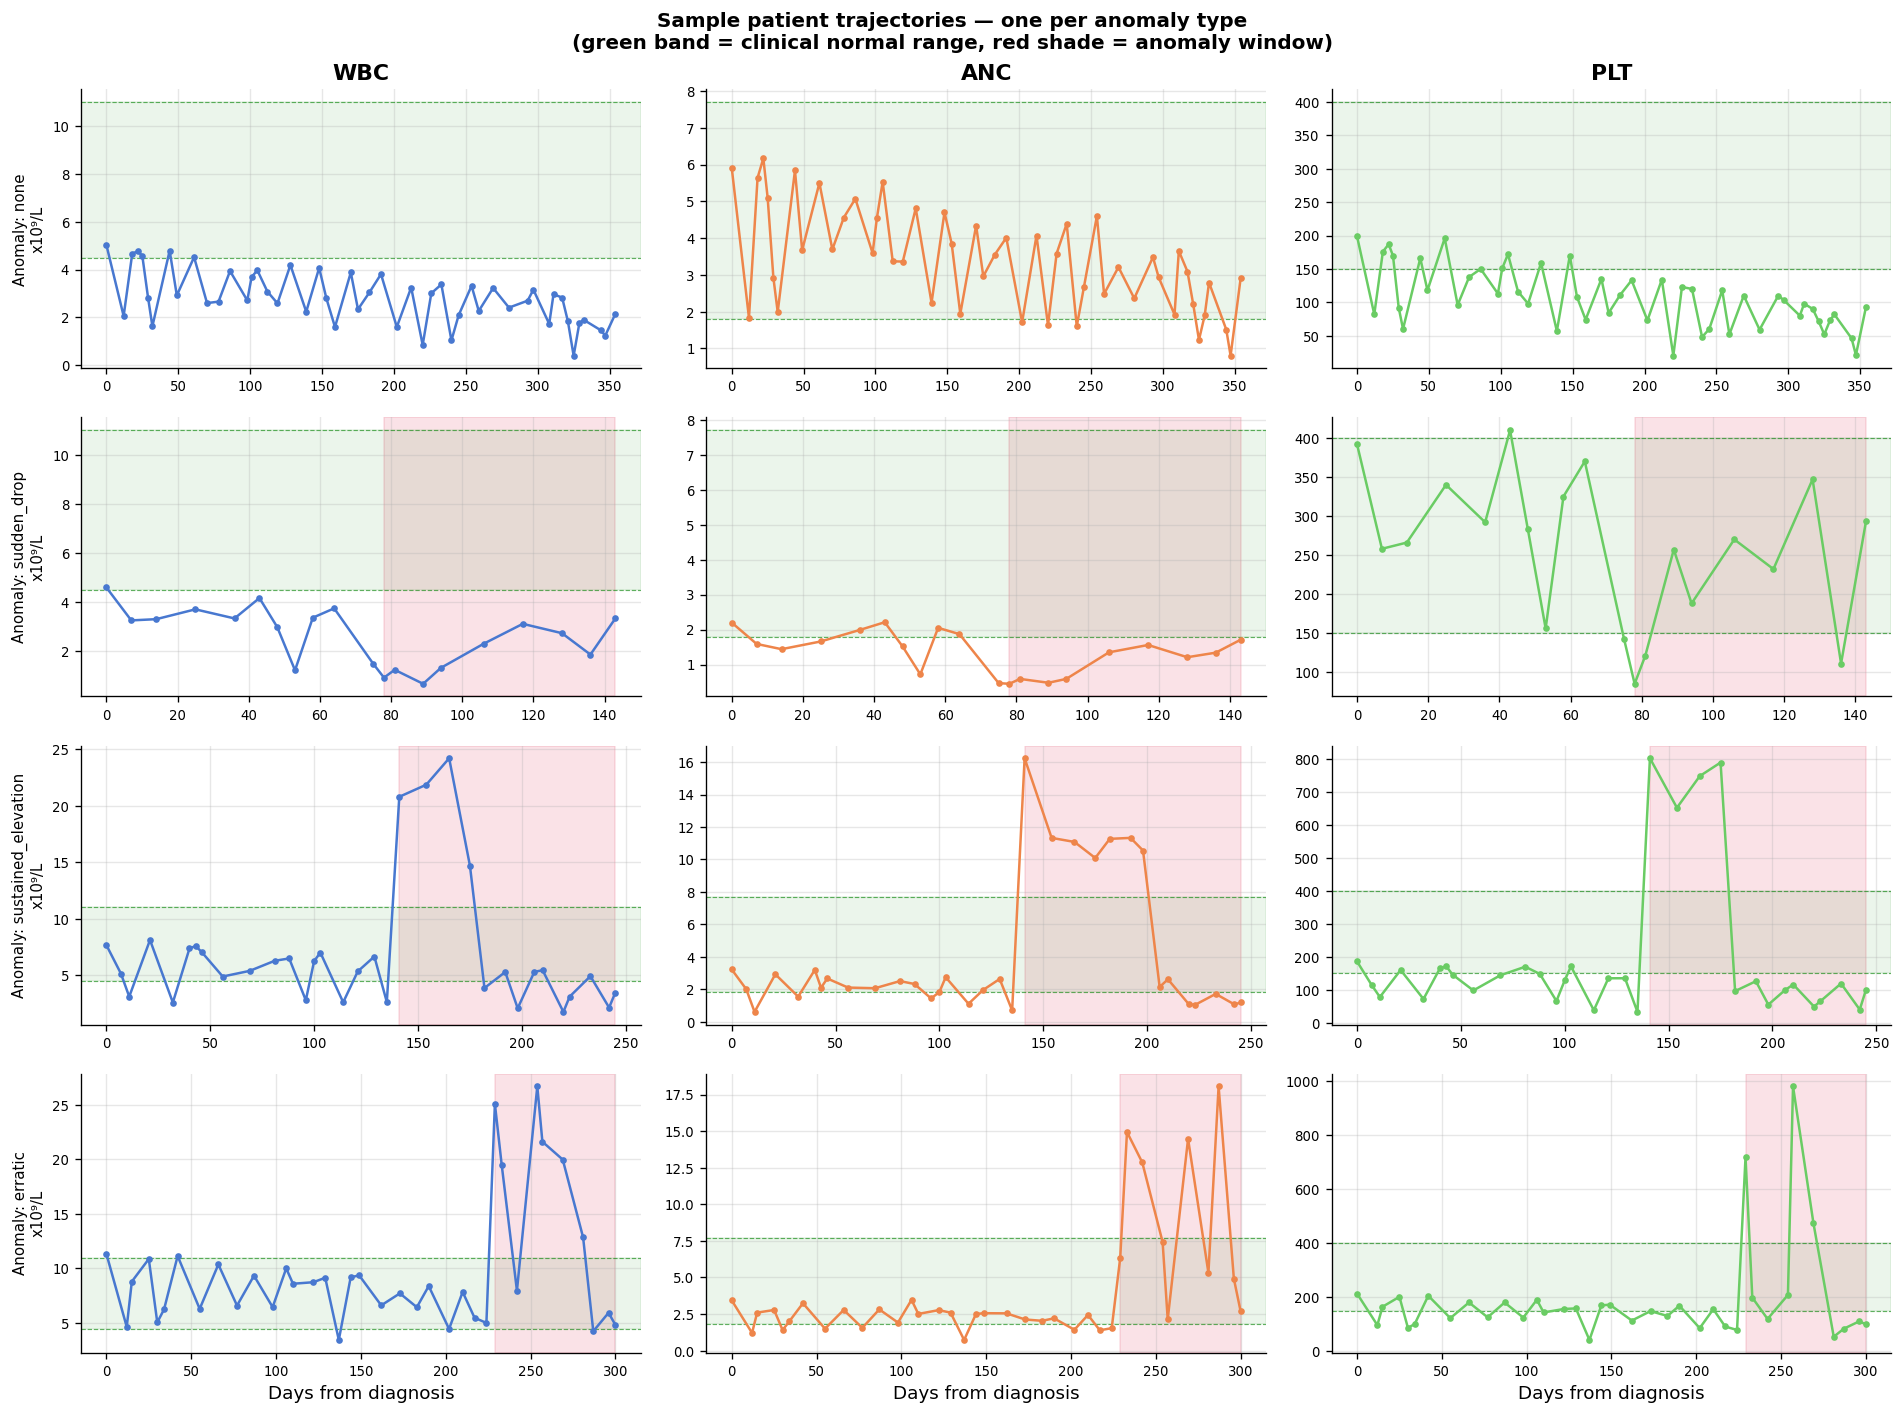

In [10]:
ANOM_TYPES = ['none', 'sudden_drop', 'sustained_elevation', 'erratic']
FEATURES_TO_PLOT = ['WBC', 'ANC', 'PLT']  # most clinically informative

fig, axes = plt.subplots(len(ANOM_TYPES), len(FEATURES_TO_PLOT),
                          figsize=(16, 12), sharex=False)

for row, atype in enumerate(ANOM_TYPES):
    # Pick first patient of this anomaly type from train set
    candidates = train_df[train_df['anomaly_type'] == atype]['patient_id'].unique()
    if len(candidates) == 0:
        continue
    pid = candidates[0]
    pt  = train_df[train_df['patient_id'] == pid].sort_values('timestamp_day')

    for col, feat in enumerate(FEATURES_TO_PLOT):
        ax = axes[row, col]
        lo, hi = NORMAL_RANGES[feat]

        # Shade anomalous draws
        anom_mask = pt['is_anomaly'].values.astype(bool)
        if anom_mask.any():
            anom_days = pt['timestamp_day'].values[anom_mask]
            ax.axvspan(anom_days.min(), anom_days.max(),
                       alpha=0.12, color='crimson', label='Anomaly window')

        # Normal range band
        ax.axhspan(lo, hi, alpha=0.08, color='green')
        ax.axhline(lo, color='green', linewidth=0.7, linestyle='--', alpha=0.6)
        ax.axhline(hi, color='green', linewidth=0.7, linestyle='--', alpha=0.6)

        # Trajectory
        ax.plot(pt['timestamp_day'], pt[feat],
                color=PALETTE[col], linewidth=1.5, marker='o',
                markersize=3, label=feat)

        if col == 0:
            ax.set_ylabel(f'Anomaly: {atype}\n{UNITS.get(feat,"")}', fontsize=9)
        if row == 0:
            ax.set_title(feat, fontweight='bold')
        if row == len(ANOM_TYPES) - 1:
            ax.set_xlabel('Days from diagnosis')

        ax.tick_params(labelsize=8)

plt.suptitle('Sample patient trajectories — one per anomaly type\n(green band = clinical normal range, red shade = anomaly window)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Window Construction Sanity Checks

In [11]:
train_windows = build_windows(train_df_t, train_ids, WINDOW_SIZE, STRIDE)
val_windows   = build_windows(val_df_t,   val_ids,   WINDOW_SIZE, STRIDE)
test_windows  = build_windows(test_df_t,  test_ids,  WINDOW_SIZE, STRIDE)

print(f'Train windows : {len(train_windows):,}')
print(f'Val   windows : {len(val_windows):,}')
print(f'Test  windows : {len(test_windows):,}')
print(f'Total         : {len(train_windows)+len(val_windows)+len(test_windows):,}')

Built 3,214 windows (skipped 0 patients with < 15 draws)
Built 644 windows (skipped 0 patients with < 15 draws)
Built 675 windows (skipped 0 patients with < 15 draws)
Train windows : 3,214
Val   windows : 644
Test  windows : 675
Total         : 4,533


In [12]:
# Check shape of a single window
sample = train_windows[0]
print('── Single window contents ──────────────────────────────')
print(f"  x_seq shape    : {sample['x_seq'].shape}   ← (T={WINDOW_SIZE}, n_seq_features=8)")
print(f"  x_static shape : {sample['x_static'].shape}   ← (n_static_features=4)")
print(f"  y shape        : {sample['y'].shape}   ← (T={WINDOW_SIZE},) anomaly label per timestep")
print(f"  meta           : {sample['meta']}")
print()
print('── x_seq first 3 timesteps ────────────────────────────')
seq_df = pd.DataFrame(
    sample['x_seq'][:3],
    columns=CBC_FEATURES + ['log_time_delta']
)
print(seq_df.round(3).to_string(index=False))

── Single window contents ──────────────────────────────
  x_seq shape    : (15, 8)   ← (T=15, n_seq_features=8)
  x_static shape : (4,)   ← (n_static_features=4)
  y shape        : (15,)   ← (T=15,) anomaly label per timestep
  meta           : {'patient_id': 473, 'window_start': 0, 'anomaly_type': 'sustained_elevation'}

── x_seq first 3 timesteps ────────────────────────────
   WBC    ANC    RBC    HGB   PLT    LYM  MONO  log_time_delta
 0.788  0.632  1.549  1.369 1.850  1.232 1.148           0.000
-0.383 -0.275 -0.033 -0.033 0.438 -0.084 0.325           2.197
-0.232 -0.230  0.011  0.020 0.366 -0.144 0.237           1.792


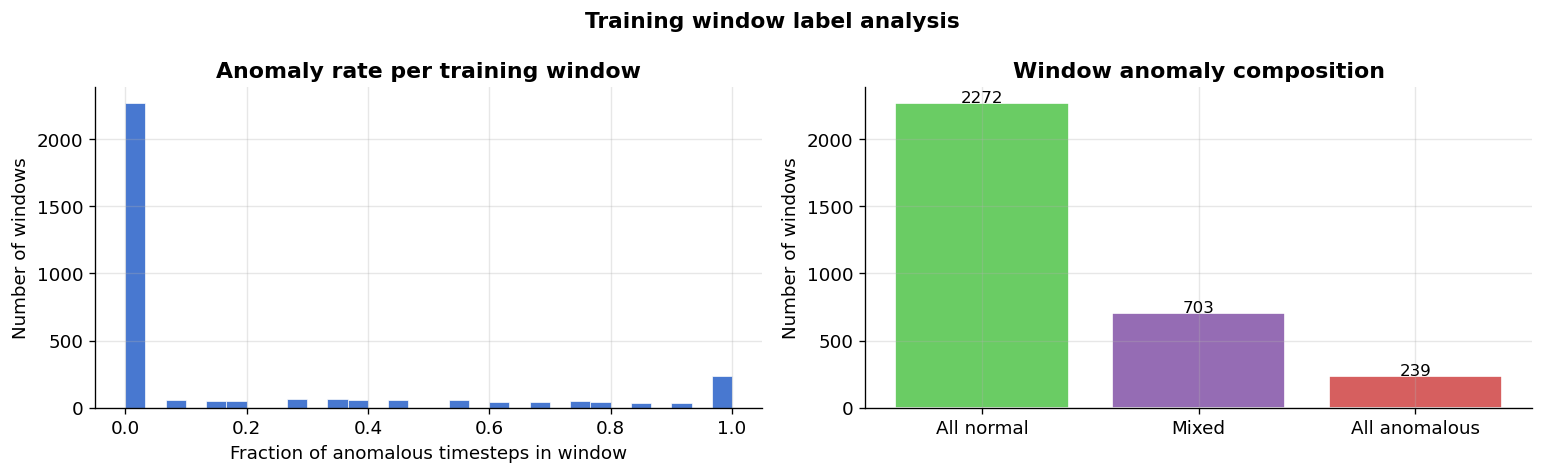

Fully normal  : 2,272  (70.7%)
Mixed         : 703  (21.9%)
Fully anomalous: 239  (7.4%)


In [13]:
# Anomaly label rate inside windows
train_anom_rates = [w['y'].mean() for w in train_windows]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of anomaly rate per window
axes[0].hist(train_anom_rates, bins=30, color=PALETTE[0], edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Fraction of anomalous timesteps in window')
axes[0].set_ylabel('Number of windows')
axes[0].set_title('Anomaly rate per training window', fontweight='bold')

# Proportion: fully normal vs mixed vs fully anomalous
fully_normal  = sum(r == 0.0 for r in train_anom_rates)
mixed         = sum(0 < r < 1 for r in train_anom_rates)
fully_anom    = sum(r == 1.0 for r in train_anom_rates)
labels = ['All normal', 'Mixed', 'All anomalous']
values = [fully_normal, mixed, fully_anom]
axes[1].bar(labels, values, color=[PALETTE[2], PALETTE[4], PALETTE[3]], edgecolor='white')
for i, (label, val) in enumerate(zip(labels, values)):
    axes[1].text(i, val + 5, str(val), ha='center', fontsize=10)
axes[1].set_ylabel('Number of windows')
axes[1].set_title('Window anomaly composition', fontweight='bold')

plt.suptitle('Training window label analysis', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Fully normal  : {fully_normal:,}  ({fully_normal/len(train_windows)*100:.1f}%)')
print(f'Mixed         : {mixed:,}  ({mixed/len(train_windows)*100:.1f}%)')
print(f'Fully anomalous: {fully_anom:,}  ({fully_anom/len(train_windows)*100:.1f}%)')

## 11. DataLoader Batch Shape Verification
Final check — confirm the shapes the model will actually receive.

In [14]:
train_loader, val_loader, test_loader = make_loaders(
    train_windows, val_windows, test_windows, batch_size=32
)

x_seq, x_static, y = next(iter(train_loader))

print('── DataLoader batch shapes ─────────────────────────────')
print(f'  x_seq    : {tuple(x_seq.shape)}')
print(f'             └─ (batch_size=32, T={WINDOW_SIZE}, n_seq_features=8)')
print(f'  x_static : {tuple(x_static.shape)}')
print(f'             └─ (batch_size=32, n_static=4)')
print(f'  y        : {tuple(y.shape)}')
print(f'             └─ (batch_size=32, T={WINDOW_SIZE})')
print()
print(f'  x_seq dtype   : {x_seq.dtype}')
print(f'  y dtype       : {y.dtype}')
print(f'  y unique vals : {y.unique().tolist()}  ← should be only 0.0 and 1.0')
print()
print(f'Train batches per epoch : {len(train_loader)}')
print(f'Val   batches per epoch : {len(val_loader)}')
print(f'Test  batches           : {len(test_loader)}')

── DataLoader batch shapes ─────────────────────────────
  x_seq    : (32, 15, 8)
             └─ (batch_size=32, T=15, n_seq_features=8)
  x_static : (32, 4)
             └─ (batch_size=32, n_static=4)
  y        : (32, 15)
             └─ (batch_size=32, T=15)

  x_seq dtype   : torch.float32
  y dtype       : torch.float32
  y unique vals : [0.0, 1.0]  ← should be only 0.0 and 1.0

Train batches per epoch : 101
Val   batches per epoch : 21
Test  batches           : 22


## 12. Summary

| Check | Status |
|---|---|
| Raw CBC features loaded | ✓ |
| Clinical normal ranges visible in histograms | ✓ |
| Anomaly types balanced (~50% none) | ✓ |
| Time delta log-scaled (reduces right skew) | ✓ |
| Patient-level train/val/test split (no leakage) | ✓ |
| Normalisation fitted on train only | ✓ |
| Post-normalisation: μ≈0, σ≈1 per feature | ✓ |
| Sliding windows constructed correctly | ✓ |
| Batch shapes confirmed for TCN input | ✓ |

**Next step:** `phase3_model.py` — build the Temporal Convolutional Network.